# Long Waveform Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
import datetime
import math
import uproot
import ROOT
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
import scipy.integrate as intg 
from scipy.stats import norm
from numpy.random import normal
import sipm.recon.WaveformAnalyzer as wfa
import sipm.recon.WaveformDataset as wfd
import sipm.util.functions as func
from datetime import datetime
from scipy.fft import fft, ifft

plt.style.use('darkside')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

Welcome to JupyROOT 6.26/08


## View raw waveforms to find out exact trigger position

trigger_position: 24950
trigger_position: 24950
trigger_position: 24950
trigger_position: 24950
trigger_position: 24950
trigger_position: 24950
trigger_position: 24950
trigger_position: 24950
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-26/2025-02-26_volt_98_light_scintillation_source_na22_random_false_cond_1000us/0/wave0.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-26/2025-02-26_volt_98_light_scintillation_source_na22_random_false_cond_1000us/0/wave1.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-26/2025-02-26_volt_98_light_scintillation_source_na22_random_false_cond_1000us/0/wave2.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-26/2025-02-26_volt_98_light_scintillation_source_na22_random_false_cond_1000us/0/wave3.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-26/2025-02-26_volt_98_light_scintillation_source_na22_random_false_cond_1000us/0/wave4.dat
10 events
/scratch/gpfs/GALBIATI/data/

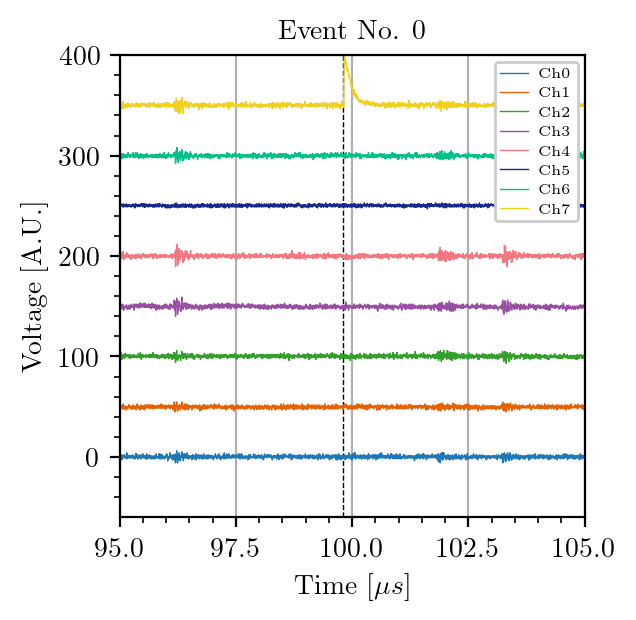

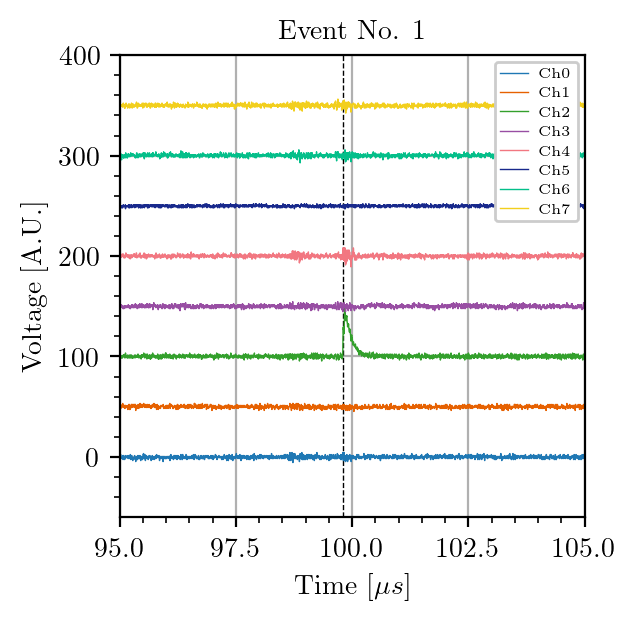

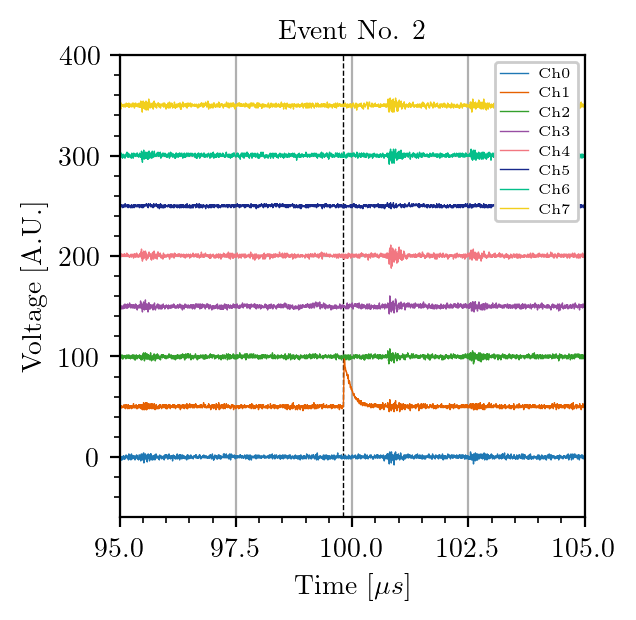

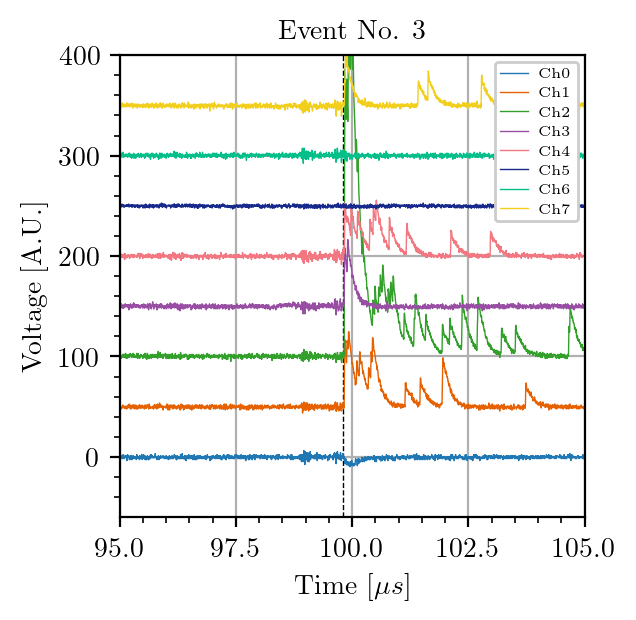

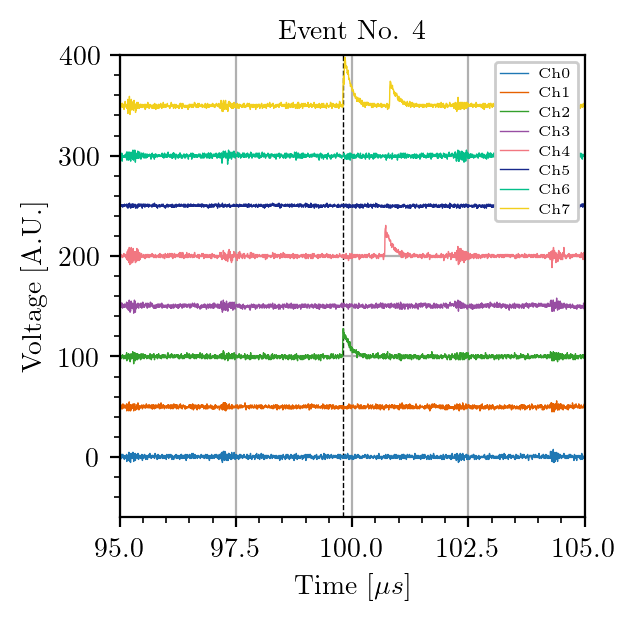

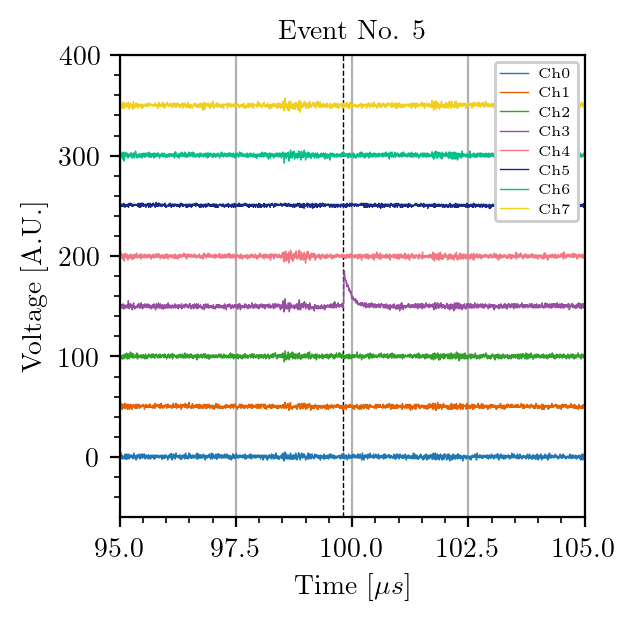

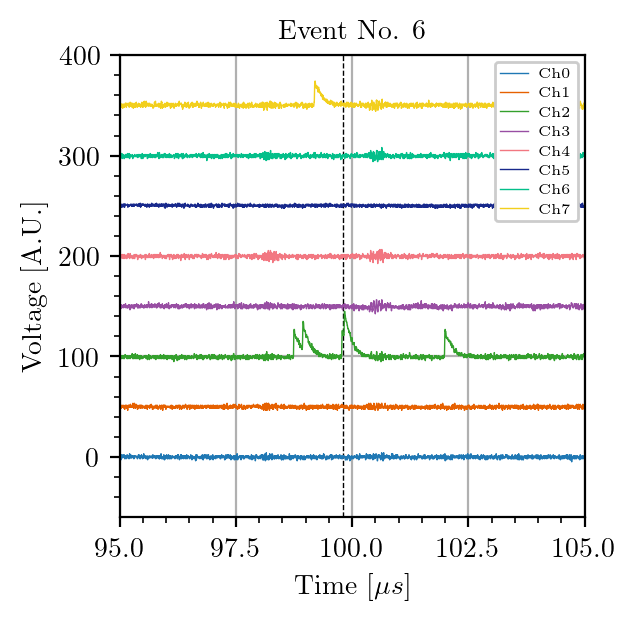

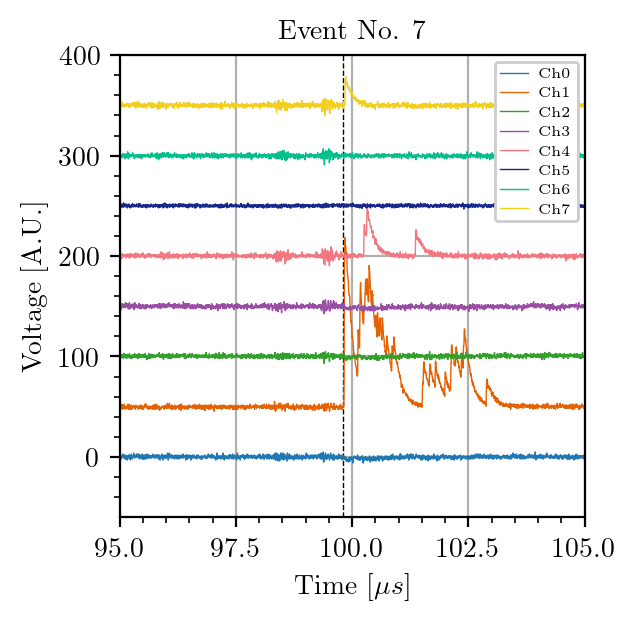

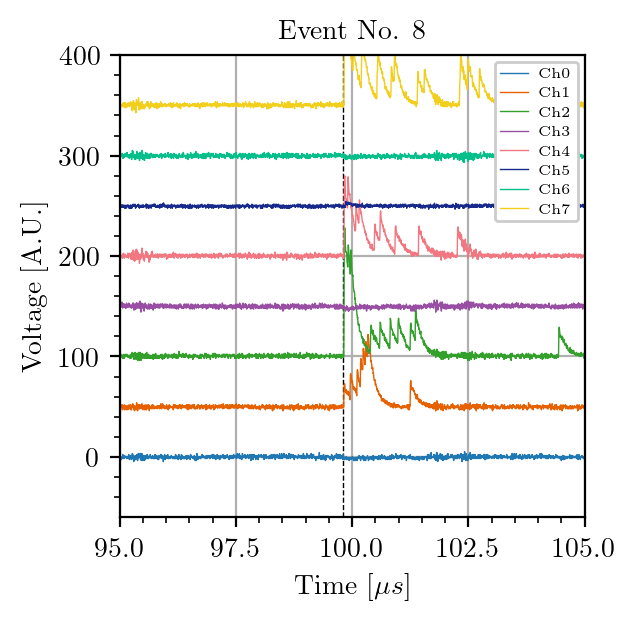

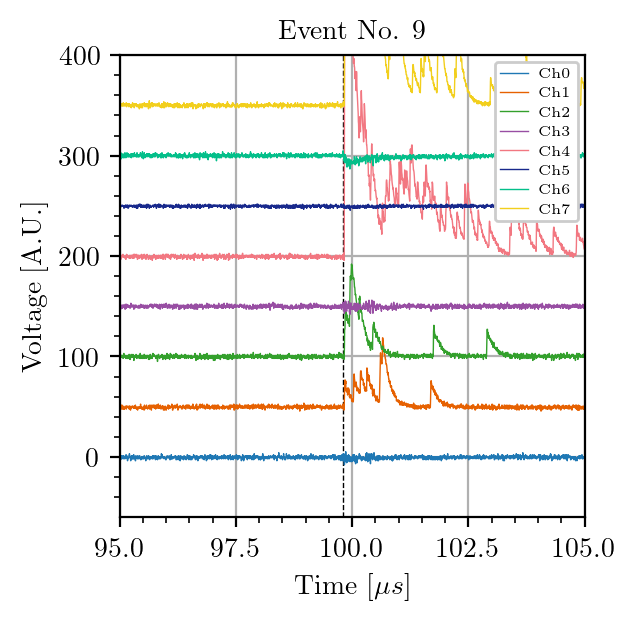

In [11]:
evid = np.arange(0, 10)
channels = [0,1,2,3,4,5,6,7]
trig = 24950
dset = wfd.WaveformDataset(
    path='/scratch/gpfs/GALBIATI/data/sipm/xart_long_wf/2025-02-26/2025-02-26_volt_98_light_scintillation_source_na22_random_false_cond_1000us/0/', 
    pol=-1, 
    channels=channels,
    trig=trig)
wfs = []
for ch in channels:
    wfs.append(dset.ch[ch].get_waveforms(ev=evid, ar_filter=False)[0])
# wfs dimensions: (channels, events, samples)
wfs = np.transpose(wfs, (1,0,2)) # (events, channels, samples)
for i,wf in enumerate(wfs):
    plt.figure(i, figsize=(3, 3))
    plt.plot([trig*4e-3]*2,[-60, 400], 'k--', lw=0.5) # show trigger position
    for j,ch in enumerate(channels):
        plt.plot(dset.ch[ch].time, wf[j]+j*50, label=f'Ch{ch}', linewidth=0.5)
    plt.legend(loc='upper right', fontsize=5)
    plt.xlabel(r'Time [$\mu s$]')
    plt.ylabel(r'Voltage [A.U.]')
    plt.minorticks_on()
    plt.grid()
    plt.xlim(95,105)
    plt.ylim(-60, 400)
    plt.title(f'Event No. {evid[i]}')

## Define functions

In [3]:
def load_data(file_list, channel_list, volt):
    df_ch = {}
    dt = 0
    for ch in channel_list:
        df_ch[ch] = []
        for f in file_list:
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            df_ch[ch].append(df)
            if ch==-1:
                dt = datetime(*np.array(df['start_datetime'][:6]).astype(int))
            df = None
        df_ch[ch] = pd.concat(df_ch[ch]).sort_index()
        if ch!=-1:
            df_ch[ch].rename(columns=lambda x: x+f'_{ch}',inplace=True)            
    df_ch = pd.concat(list(df_ch.values()),axis=1)
    return df_ch, dt

def get_bsl_filt(df_data,channels,rms_thre_ch):
    df_bsl_filt = {}
    for ch in channels:
        df_bsl_filt[f'bsl_filt_{ch}'] = df_data[f'baseline_rms_{ch}']<rms_thre_ch[ch]
        # print(df_bsl_filt[f'bsl_filt_{ch}'].sum())
    df_bsl_filt = pd.DataFrame(df_bsl_filt)
    df_bsl_filt['bsl_filt'] =  df_bsl_filt[[f'bsl_filt_{ch}' for ch in channels]].all(axis=1)
    return df_bsl_filt

def get_bsl_rms_hist(df_data,channels,bins,range):
    hist_ch = {}
    for ch in channels:
        hist_ch[ch] = np.histogram(df_data[f'baseline_rms_{ch}'], bins=bins, range=range)
    return hist_ch

def get_bsl_mean_hist(df_data,channels,bsl_filt,bins,range):
    hist_ch = {}
    for ch in channels:
        if bsl_filt:
            hist_ch[ch] = np.histogram(df_data.loc[df_data[f'bsl_filt_{ch}'],f'baseline_mean_{ch}'], bins=bins, range=range)
        else:
            hist_ch[ch] = np.histogram(df_data[f'baseline_mean_{ch}'], bins=bins, range=range)
    return hist_ch

## Organize file paths

In [4]:
path = "/scratch/gpfs/as111/results/"
random = ['true', 'false']
files = {'true': glob(f'{path}2025-02-14/*random_true*long_wf_pulse_liq8.h5'),
         'false': glob(f'{path}2025-02-13/*random_false*long_wf_pulse_liq8.h5')}
for k,v in files.items():
	print(k,len(v))

true 2
false 2


## Read data

In [5]:
data = {}
channels = [0,1,2,3,4,7]
volt = 98
for r,f in files.items():
	df, _ = load_data(f, [-1]+channels, volt)
	data[r] = df
	print(f'random: {r} {df.shape[0]} events')
print('columns: ', list(data[random[0]].columns))

random: true 10055 events
random: false 10004 events
columns:  ['start_datetime', 'end_datetime', 'duration_seconds', 'total_pe', 'fprompt_0p30us_1247', 'baseline_mean_0', 'baseline_rms_0', 'integral_0p30us_0', 'integral_10p00us_0', 'amplitude_0', 'peakpos_0', 'baseline_mean_1', 'baseline_rms_1', 'integral_0p30us_1', 'integral_10p00us_1', 'amplitude_1', 'peakpos_1', 'baseline_mean_2', 'baseline_rms_2', 'integral_0p30us_2', 'integral_10p00us_2', 'amplitude_2', 'peakpos_2', 'baseline_mean_3', 'baseline_rms_3', 'integral_0p30us_3', 'integral_10p00us_3', 'amplitude_3', 'peakpos_3', 'baseline_mean_4', 'baseline_rms_4', 'integral_0p30us_4', 'integral_10p00us_4', 'amplitude_4', 'peakpos_4', 'baseline_mean_7', 'baseline_rms_7', 'integral_0p30us_7', 'integral_10p00us_7', 'amplitude_7', 'peakpos_7']


## Pre-trigger RMS cut

In [6]:
rms_threshold = {0:2.0, 1:2.0, 2:2.0, 3:2.0, 4:2.0, 7:2.0}
for r in random:
    df_bsl_filt = get_bsl_filt(data[r],[0,1,2,3,4,7],rms_threshold)
    data[r][df_bsl_filt.columns] = df_bsl_filt
    df_bsl_filt = None

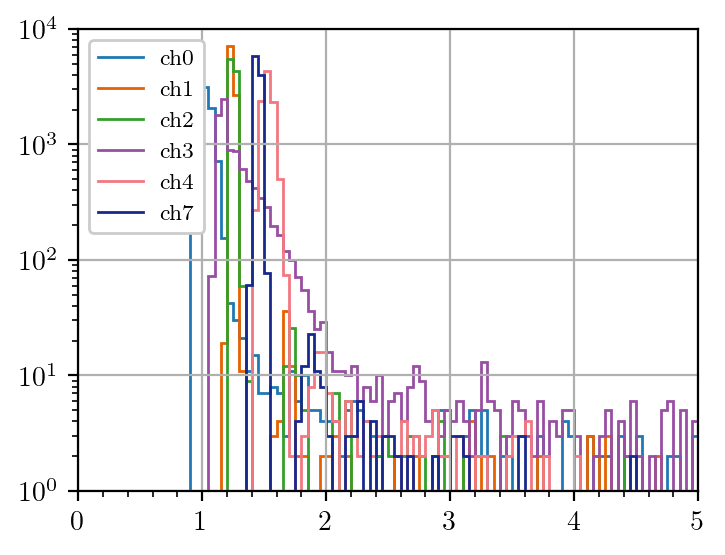

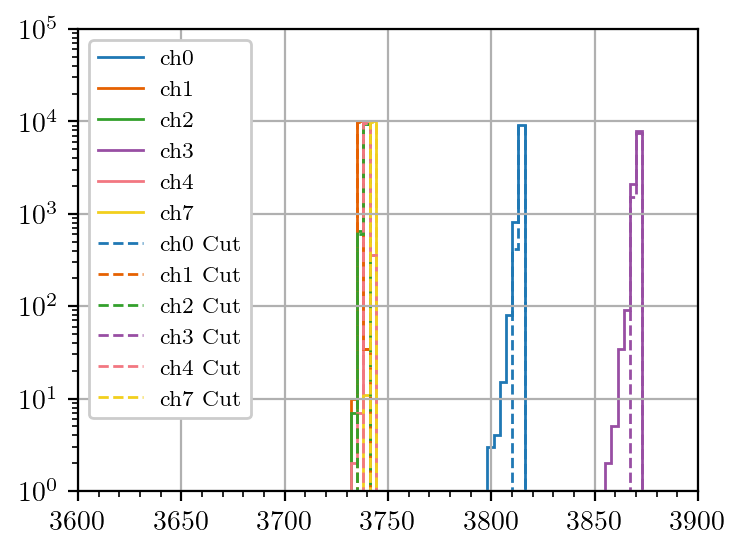

In [7]:
r = 'true'

plt.figure(0)
hists = get_bsl_rms_hist(data[r],channels,100,(0,5))
for ch,hist in hists.items():
	plt.stairs(*(hist),label=f'ch{ch}')
plt.legend()
plt.yscale('log')
plt.grid()
plt.minorticks_on()

plt.figure(1)
hists_nc = get_bsl_mean_hist(data[r],channels,False,100,(3600,3900))
hists_ac = get_bsl_mean_hist(data[r],channels,True,100,(3600,3900))
for ch,hist in hists_nc.items():
	plt.stairs(*(hist),color=f'C{ch}',label=f'ch{ch} ')
for ch,hist in hists_ac.items():
	plt.stairs(*(hist),color=f'C{ch}',label=f'ch{ch} Cut',ls='--')
plt.legend()
plt.yscale('log')
plt.grid()
plt.minorticks_on()

## Npe - Fprompt Distributions

In [ ]:
nbinsx = 500
range_minx = 0
range_maxx = 400
nbinsy = 500
range_miny = 0
range_maxy = 1

pe_fp = {}
for r in random:
    pe_fp[r] = {}
    bsl_filt = data[r]['bsl_filt']
    pe_fp[r]['counts'], pe_fp[r]['xbins'], pe_fp[r]['ybins'] = np.histogram2d(
        data[r]['total_pe'][bsl_filt], # x-axis
        data[r]['fprompt_0p30us_1247'][bsl_filt], # y-axis
        bins=[nbinsx,nbinsy], range=[[range_minx,range_maxx],[range_miny,range_maxy]]
    )
    pe_fp[r]['counts'] = pe_fp[r]['counts'].T
    pe_fp[r]['xbins'], pe_fp[r]['ybins'] = np.meshgrid(
        pe_fp[r]['xbins'], pe_fp[r]['ybins']
    )

/tmp/ipykernel_624960/926400680.py:11: RuntimeWarning: divide by zero encountered in log10
  np.log10(pe_fp[r]['counts'])


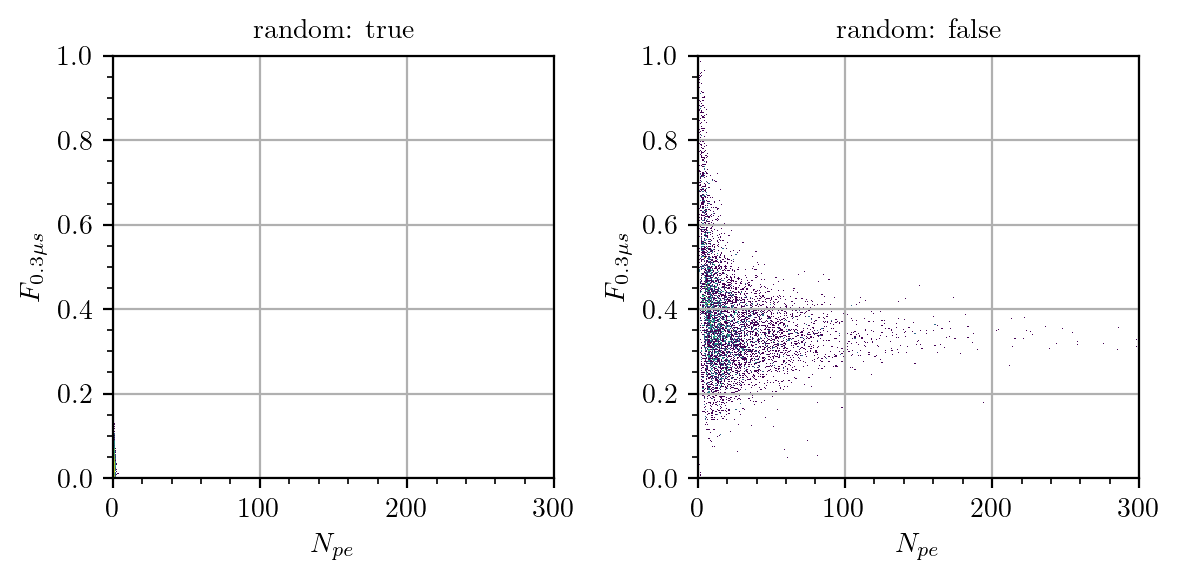

In [9]:
ncols = 2
nrows = len(random)//ncols
fig, axs = plt.subplots(nrows, ncols, sharex=False, sharey=False)

fig.set_size_inches(3*ncols, 3*nrows)

for i, r in enumerate(random):
    axs[i%ncols].pcolormesh(
        pe_fp[r]['xbins'],
        pe_fp[r]['ybins'],
        np.log10(pe_fp[r]['counts'])
    )
    axs[i%ncols].minorticks_on()
    axs[i%ncols].grid()
    axs[i%ncols].set_title(f'random: {r}')
    axs[i%ncols].set_xlim(0, 300)
    axs[i%ncols].set_ylim(0, 1)
    axs[i%ncols].set_xlabel(r'$N_{pe}$')
    axs[i%ncols].set_ylabel(r'$F_{0.3\mu s}$')
    
# Adjust layout to prevent overlap
fig.tight_layout()

# BaF2 Spectra

In [10]:
nbinsx = 500
range_minx = 0
range_maxx = 1.5e5
nbinsy = 500
range_miny = 0
range_maxy = 1.5e5

d1_d2_itg = {}
for r in random:
    d1_d2_itg[r] = {}
    bsl_filt = data[r]['bsl_filt']
    d1_d2_itg[r]['counts'], d1_d2_itg[r]['xbins'], d1_d2_itg[r]['ybins'] = np.histogram2d(
        data[r]['integral_10p00us_0'][bsl_filt], 
        data[r]['integral_10p00us_3'][bsl_filt], 
        bins=[nbinsx,nbinsy], range=[[range_minx,range_maxx],[range_miny,range_maxy]]
    )
    d1_d2_itg[r]['counts'] = d1_d2_itg[r]['counts'].T
    d1_d2_itg[r]['xbins'], d1_d2_itg[r]['ybins'] = np.meshgrid(
        d1_d2_itg[r]['xbins'], d1_d2_itg[r]['ybins']
    )

/tmp/ipykernel_624960/1160701444.py:9: RuntimeWarning: divide by zero encountered in log10
  np.log10(d1_d2_itg[r]['counts'])


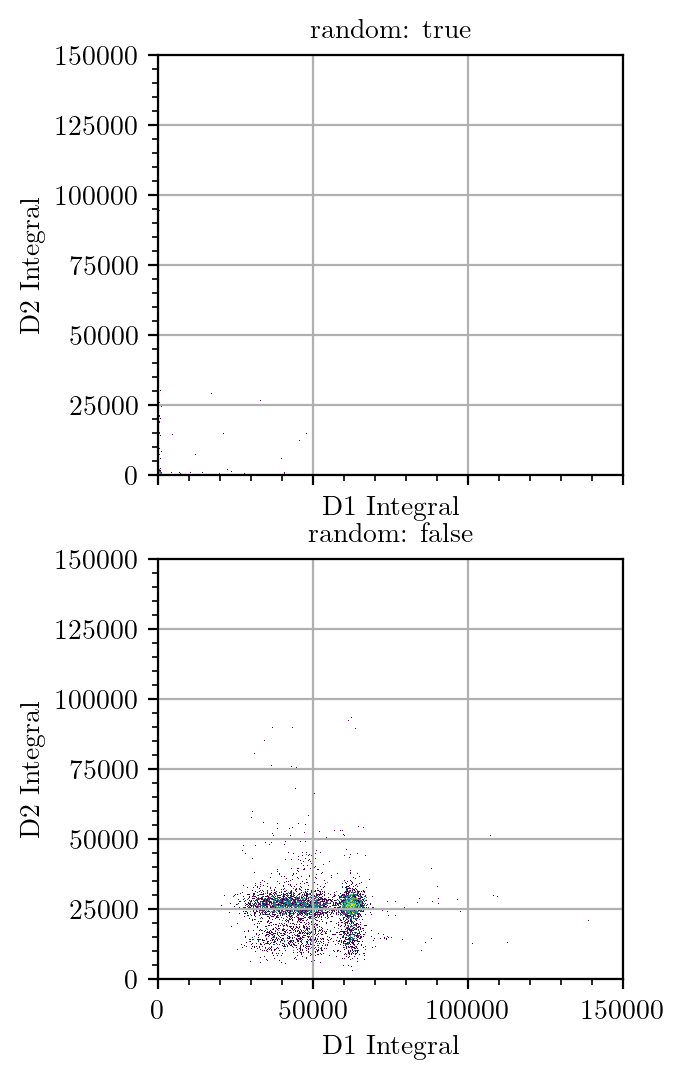

In [11]:
nrows = 2
fig, axs = plt.subplots(nrows, 1, sharex=True, sharey=True)
fig.set_size_inches(3, 3*nrows)

for i, r in enumerate(random):
    axs[i].pcolormesh(
        d1_d2_itg[r]['xbins'],
        d1_d2_itg[r]['ybins'],
        np.log10(d1_d2_itg[r]['counts'])
    )
    axs[i].minorticks_on()
    axs[i].grid()
    axs[i].set_title(f'random: {r}')
    axs[i].set_xlim(0, 1.5e5)
    axs[i].set_ylim(0, 1.5e5)
    axs[i].set_xlabel(r'D1 Integral')
    axs[i].set_ylabel(r'D2 Integral')

## Average waveform shape

In [12]:
def downsample(input_t,input_wf,nsub):
    ntot = int(input_t.shape[0]//nsub * nsub)
    new_t, new_wf = np.zeros(ntot//nsub), np.zeros(ntot//nsub)
    for i in range(nsub):
        new_t += input_t[i:ntot:nsub]
        new_wf += input_wf[i:ntot:nsub]
    new_t /= nsub
    new_wf /= nsub
    return new_t, new_wf

In [14]:
path = "/scratch/gpfs/as111/results/"
random = ['true', 'false']
files = {'true': glob(f'{path}2025-02-27/*random_true*long_wf_shape_liq8.h5'),
         'false': glob(f'{path}2025-02-26/*random_false*long_wf_shape_liq8.h5')}
for k,v in files.items():
	print(k,len(v))

true 20
false 20


In [15]:
# data folder
data_scint = {}
channels = [0,1,2,3,4,5,6,7]
ch_old = [0,5,6,3,4,1,2,7] # map to channels in liq5 calibration data
volt = 98
for r,fs in files.items():
    data_scint[r] = {}
    for j,f in enumerate(fs):
        df = pd.read_hdf(f, key=f'{volt}/-1')
        for ch in channels:
            if j==0:
                data_scint[r][ch] = {'n_scint_wfs':0, 'avg_scint_wf':np.zeros(0), 'time':np.zeros(0)}
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            data_scint[r][ch]['n_scint_wfs'] += np.array(df['n_scint_wfs'])[0]
            if data_scint[r][ch]['time'].shape[0]==0:
                data_scint[r][ch]['time'] = np.array(df['time'].dropna())
            if data_scint[r][ch]['avg_scint_wf'].shape[0]==0:
                data_scint[r][ch]['avg_scint_wf'] = np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            else:
                data_scint[r][ch]['avg_scint_wf'] += np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            df = None

for r,fs in files.items():
    for ch in channels:
        data_scint[r][ch]['avg_scint_wf'] /= data_scint[r][ch]['n_scint_wfs']

random: true ch0 100223 waveforms selected
random: false ch0 100216 waveforms selected
random: true ch1 100223 waveforms selected
random: false ch1 100216 waveforms selected
random: true ch2 100223 waveforms selected
random: false ch2 100216 waveforms selected
random: true ch3 100223 waveforms selected
random: false ch3 100216 waveforms selected
random: true ch4 100223 waveforms selected
random: false ch4 100216 waveforms selected
random: true ch5 100223 waveforms selected
random: false ch5 100216 waveforms selected
random: true ch6 100223 waveforms selected
random: false ch6 100216 waveforms selected
random: true ch7 100223 waveforms selected
random: false ch7 100216 waveforms selected


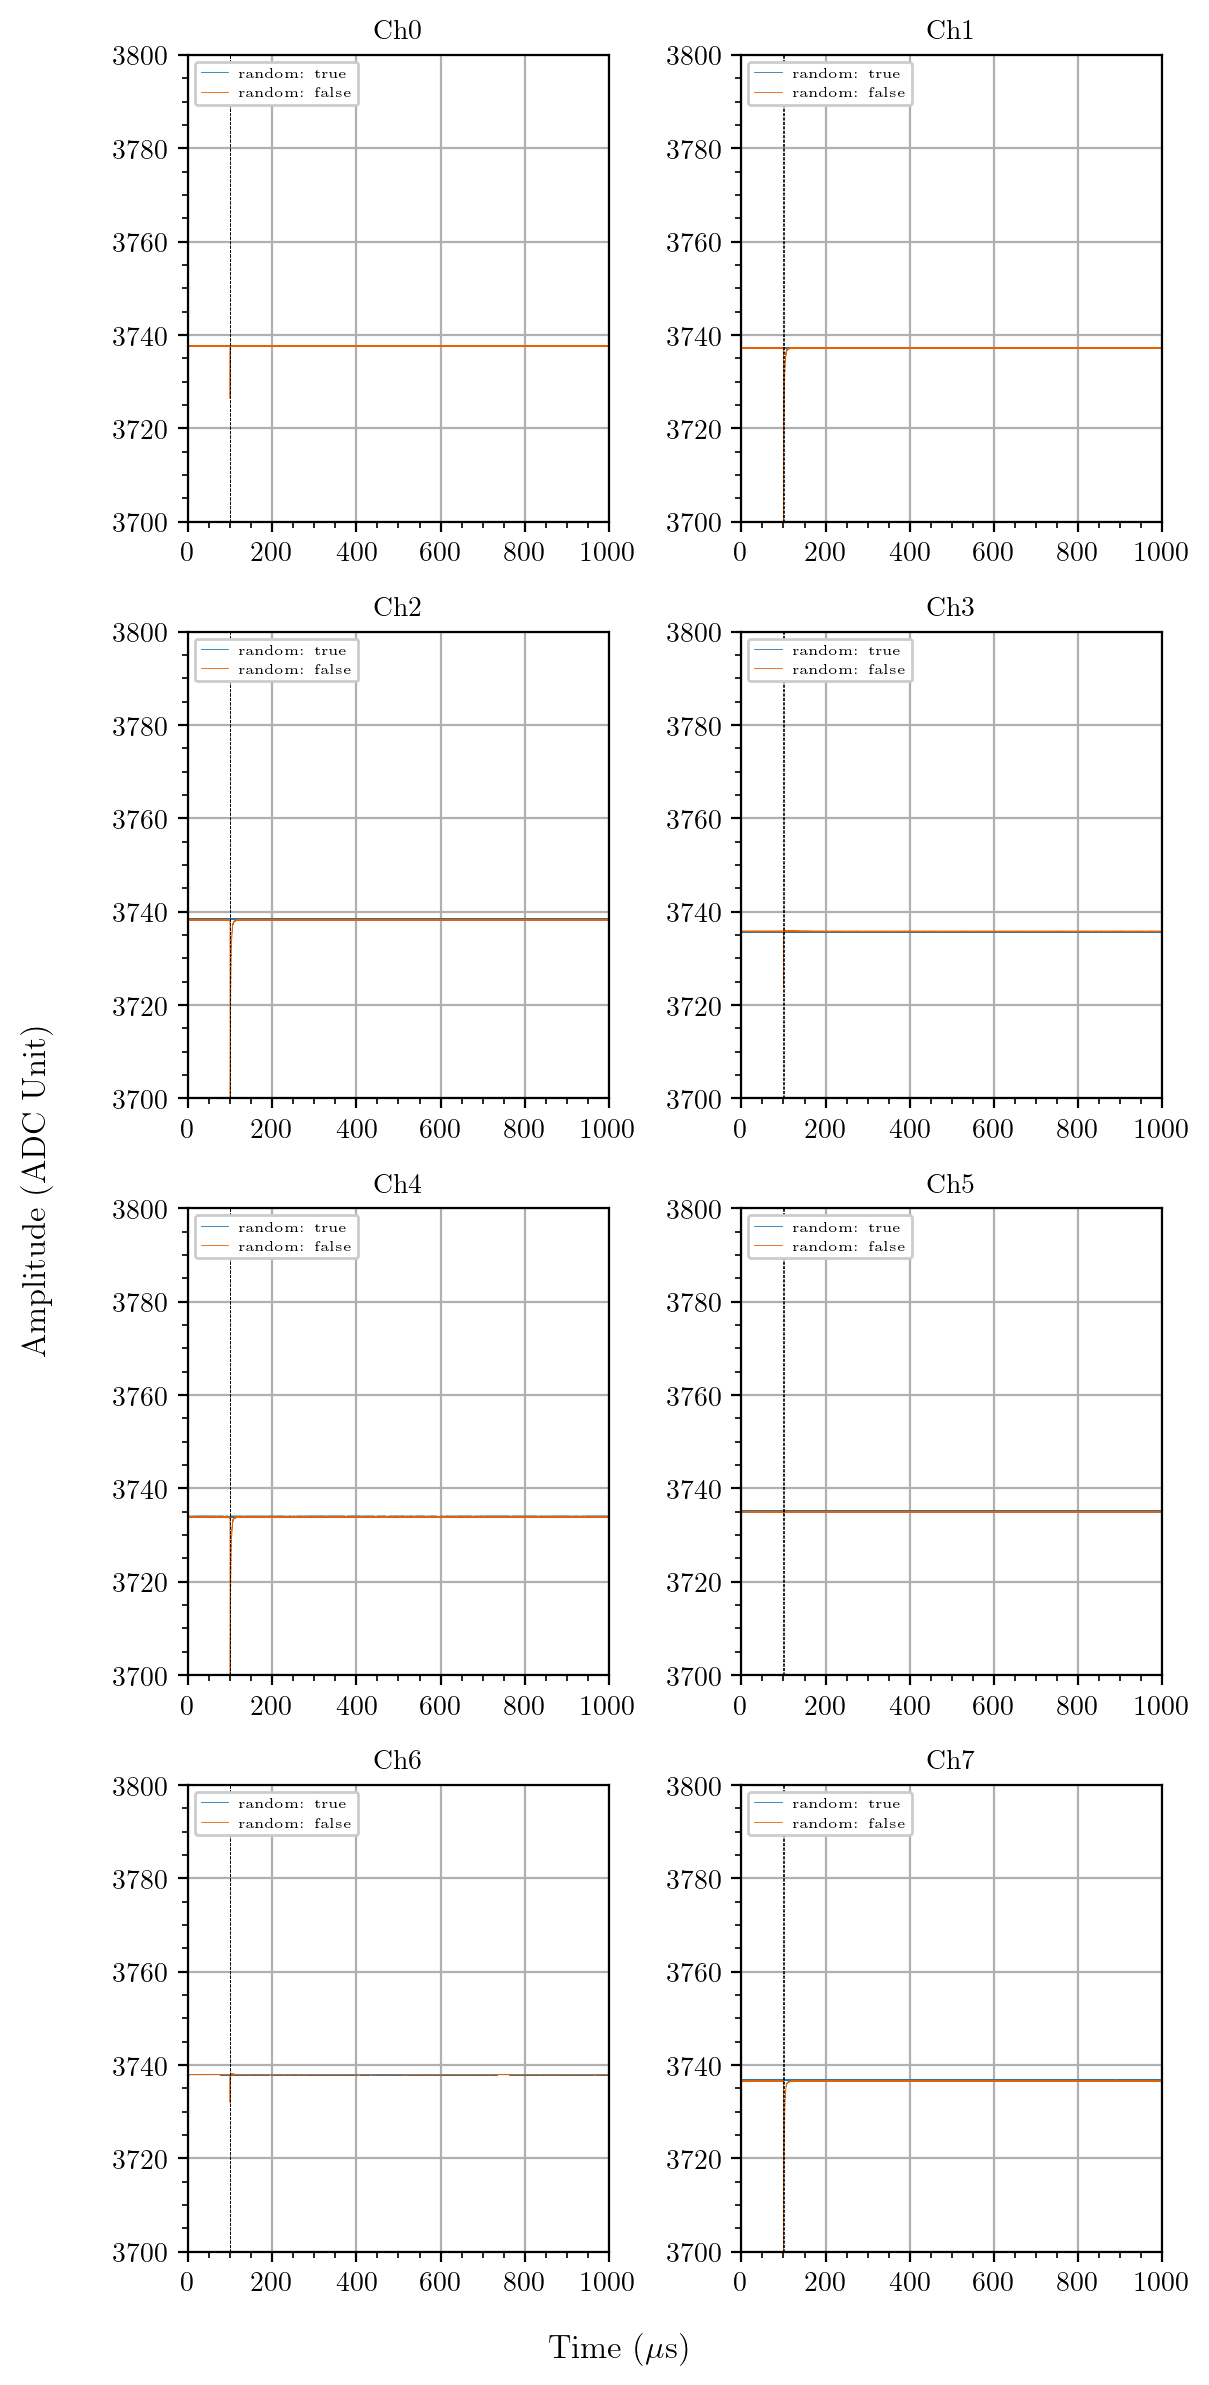

In [18]:
# Make plots for all datasets
# Average LAr scintillation waveform
t_trig = 24950*4e-3
ylims = (3700,3800)
fig, axs = plt.subplots(4, 2, sharex=False, sharey=False)
fig.set_size_inches(6, 12)
for j, ch in enumerate(channels):
    for r in random:
        print(f'random: {r} ch{ch} {data_scint[r][ch]["n_scint_wfs"]:.0f} waveforms selected')
        axs[j//2, j%2].plot(
            data_scint[r][ch]['time'],
            data_scint[r][ch]['avg_scint_wf'],
            label=f'random: {r}', linewidth=0.3)
    axs[j//2, j%2].legend(loc='upper left',fontsize=5)
    # axs[j//2, j%2].set_xlim(0, 10)
    axs[j//2, j%2].set_ylim(*ylims)
    # axs[j//2, j%2].set_yscale('log')
    axs[j//2, j%2].minorticks_on()
    axs[j//2, j%2].grid()
    axs[j//2, j%2].set_title(f'Ch{ch}')
    axs[j//2, j%2].plot([t_trig-10*0.004]*2, ylims, 'k--',linewidth=0.3)
    axs[j//2, j%2].plot([t_trig+0.3]*2, ylims, 'k--',linewidth=0.3)
fig.supxlabel(r'Time ($\mu$s)', y=0.01)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.00)
fig.tight_layout()

## Summation + Downsampling

In [24]:
# summation
for r in random:
    data_scint[r][-1] = {
        'time': data_scint[r][channels[0]]['time'], 
        'sum_ww': np.zeros(data_scint[r][channels[0]]['time'].shape[0]),
        'sum_wl': np.zeros(data_scint[r][channels[0]]['time'].shape[0])}
    for ch in [1,2,4,7]: # wl
        data_scint[r][-1]['sum_wl'] += data_scint[r][ch]['avg_scint_wf']
    data_scint[r][-1]['sum_wl'] /= 4
    for ch in [0,3,5,6]: # ww
        data_scint[r][-1]['sum_ww'] += data_scint[r][ch]['avg_scint_wf']
    data_scint[r][-1]['sum_ww'] /= 4

In [25]:
# downsampling
nsub = 10
for r in random:
    data_scint[r][-1]['time_sub'], data_scint[r][-1]['sum_wl_sub'] = downsample(data_scint[r][-1]['time'],data_scint[r][-1]['sum_wl'],nsub)
    data_scint[r][-1]['time_sub'], data_scint[r][-1]['sum_ww_sub'] = downsample(data_scint[r][-1]['time'],data_scint[r][-1]['sum_ww'],nsub)

Text(0.5, 1.0, 'WW SiPMs')

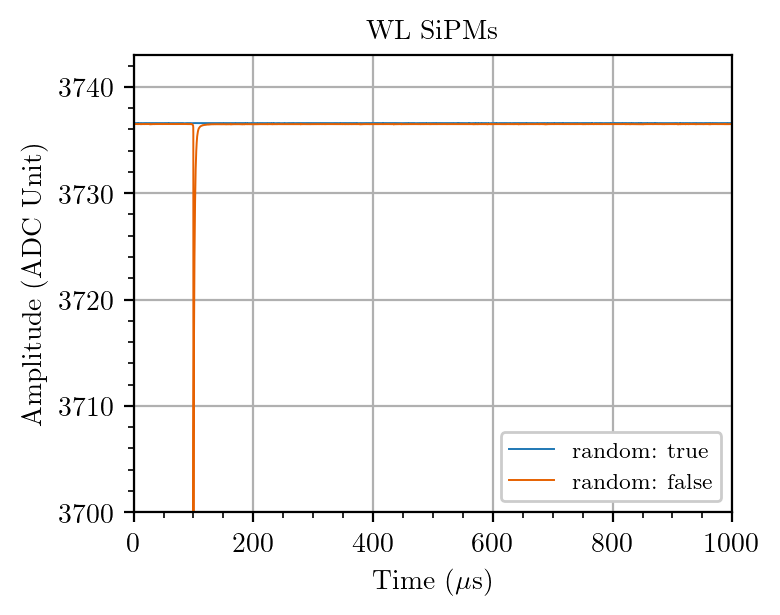

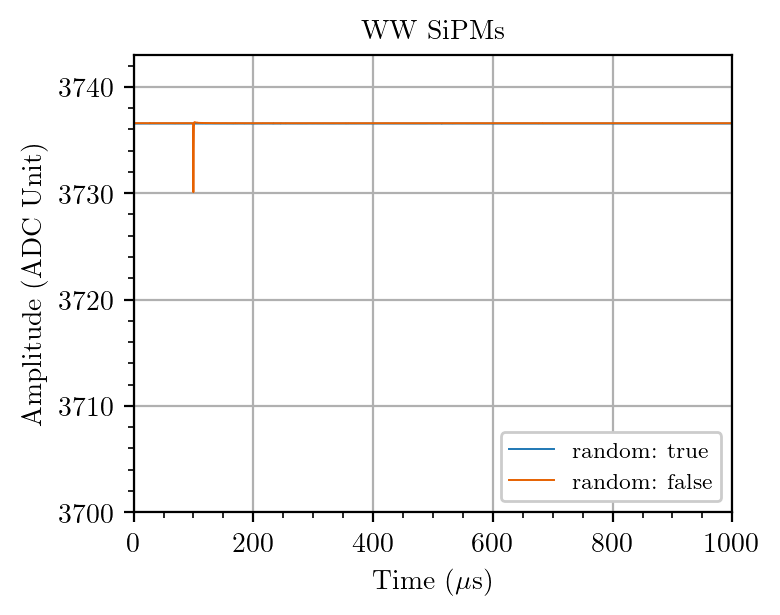

In [27]:
# Make plots for all datasets
# Summed scintillation waveform
plt.figure(0,figsize=(4,3))
for i,r in enumerate(random):
    plt.plot(
		data_scint[r][-1]['time_sub'],
		data_scint[r][-1]['sum_wl_sub'],linewidth=0.7, label=f'random: {r}')
plt.ylim(3700, 3743)
# plt.xlim(39,41)
plt.minorticks_on()
plt.grid()
plt.legend(loc='lower right')
plt.xlabel(r'Time ($\mu$s)', y=0.0)
plt.ylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()
plt.title('WL SiPMs')

plt.figure(1,figsize=(4,3))
for i,r in enumerate(random):
    plt.plot(
		data_scint[r][-1]['time_sub'],
		data_scint[r][-1]['sum_ww_sub'],linewidth=0.7, label=f'random: {r}')
plt.ylim(3700, 3743)
# plt.xlim(39,41)
plt.minorticks_on()
plt.grid()
plt.legend(loc='lower right')
plt.xlabel(r'Time ($\mu$s)', y=0.0)
plt.ylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()
plt.title('WW SiPMs')

Text(0.5, 1.0, 'WW SiPMs')

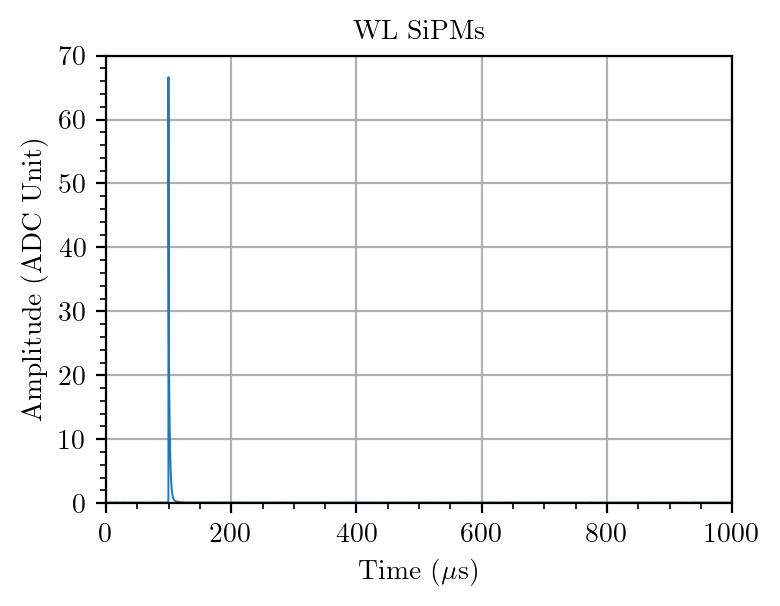

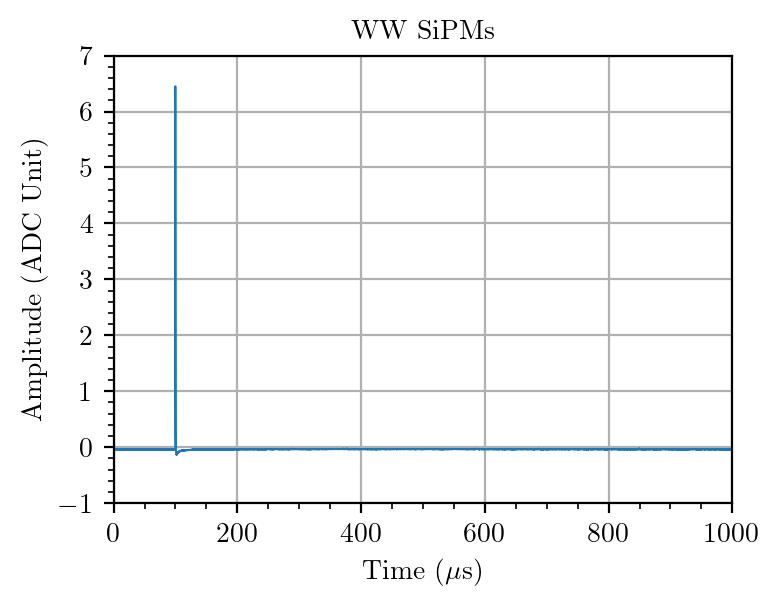

In [30]:
# Make plots for all datasets
# Summed scintillation waveform
plt.figure(0,figsize=(4,3))
plt.plot(
	data_scint['true'][-1]['time_sub'],
	data_scint['true'][-1]['sum_wl_sub']-data_scint['false'][-1]['sum_wl_sub'],linewidth=0.7, label=f'random: {r}')
# plt.ylim(-0.1, 0.5)
# plt.xlim(30,140)
# plt.yscale('log')
plt.minorticks_on()
plt.grid()
# plt.legend(loc='upper right')
plt.xlabel(r'Time ($\mu$s)', y=0.0)
plt.ylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()
plt.title('WL SiPMs')

plt.figure(1,figsize=(4,3))
plt.plot(
	data_scint['true'][-1]['time_sub'],
	data_scint['true'][-1]['sum_ww_sub']-data_scint['false'][-1]['sum_ww_sub'],linewidth=0.7, label=f'random: {r}')
# plt.ylim(-0.1, 0.5)
# plt.xlim(30,140)
# plt.yscale('log')
plt.minorticks_on()
plt.grid()
# plt.legend(loc='upper right')
plt.xlabel(r'Time ($\mu$s)', y=0.0)
plt.ylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()
plt.title('WW SiPMs')

In [32]:
t0 = 100
def exp3(t, a1, tau1, a2, tau2, a3, tau3):
    t = t-t0
    return a1*np.exp(-t/tau1)+a2*np.exp(-t/tau2)+a3*np.exp(-t/tau3)

[3.31426934e+01 1.72590443e+00 5.70190393e-01 8.87681288e+00
 1.07291747e-02 9.20780885e+02]


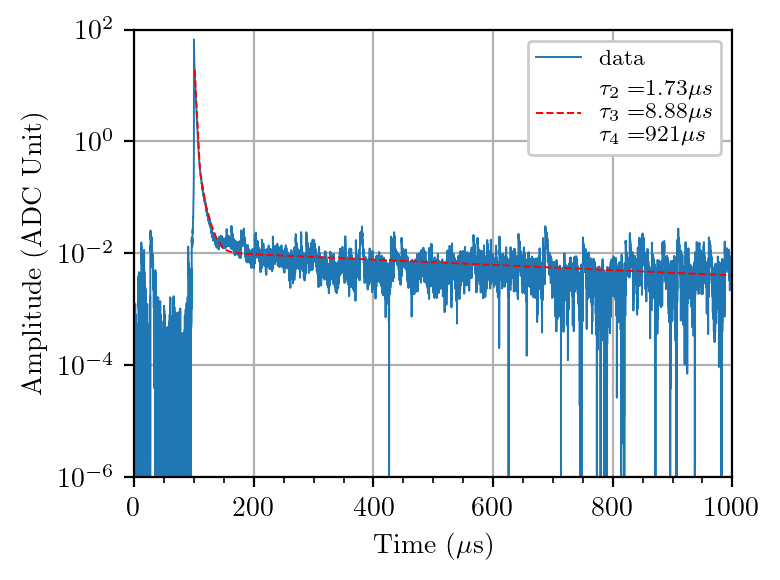

In [ ]:
bsl = data_scint['false'][-1]['sum_wl_sub'][data_scint['false'][-1]['time_sub']<90].mean()
rms = data_scint['false'][-1]['sum_wl_sub'][data_scint['false'][-1]['time_sub']<90].std()
print(bsl,rms)
# Make plots for all datasets
# Summed scintillation waveform
plt.figure(0,figsize=(4,3))
plt.plot(
	data_scint['false'][-1]['time_sub'],
	bsl-data_scint['false'][-1]['sum_wl_sub'],linewidth=0.7,label='data')
# plt.ylim(-0.1, 0.5)
plt.xlim(0,1000)
plt.yscale('log')
plt.minorticks_on()
plt.grid()

plt.xlabel(r'Time ($\mu$s)', y=0.0)
plt.ylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()

t_arr = np.linspace(101,1000,100)
# plt.plot(t_arr,exp3(t_arr,
#                     200,1.5,
#                     3,8,
#                     0.06,200),'r--',lw=0.5)
ydata = bsl-data_scint['false'][-1]['sum_wl_sub'][data_scint['false'][-1]['time_sub']>101]
xdata = data_scint['false'][-1]['time_sub'][data_scint['false'][-1]['time_sub']>101]
par,cov = curve_fit(exp3,
					xdata,
					ydata,
					p0=[200,1.5,3,8,0.06,200],sigma=rms*np.ones_like(ydata))
print(par)
plt.plot(t_arr,exp3(t_arr,*par),'r--',lw=0.7,label=r'$\tau_2=$'+f'{par[1]:.2f}'+r'$\mu s$'+'\n'
         + r'$\tau_3=$'+f'{par[3]:.2f}'+r'$\mu s$'+'\n'
         + r'$\tau_4=$'+f'{par[5]:.0f}'+r'$\mu s$')
plt.legend(loc='upper right')
plt.title('WL SiPMs')

3736.590390351064 0.0012538586271066854
[-8.82615884e-02  5.45105120e+00 -2.00225695e-02  4.37827379e+01
  4.69461404e-03  1.45048246e+03]


/tmp/ipykernel_2061318/804424517.py:4: RuntimeWarning: overflow encountered in exp
  return a1*np.exp(-t/tau1)+a2*np.exp(-t/tau2)+a3*np.exp(-t/tau3)
/home/as111/miniconda3/envs/sipm/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:504: RuntimeWarning: overflow encountered in multiply
  return transform * (func(xdata, *params) - ydata)


Text(0.5, 1.0, 'WW SiPMs')

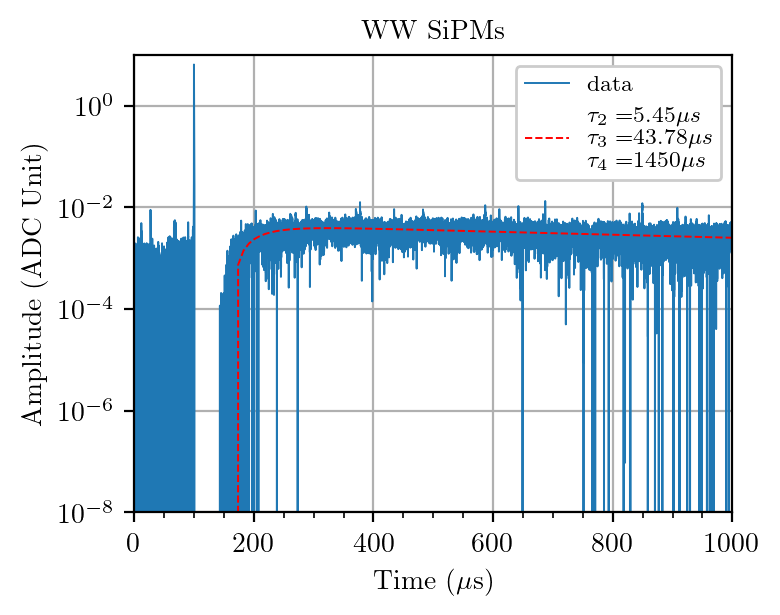

In [34]:
bsl = data_scint['false'][-1]['sum_ww_sub'][data_scint['false'][-1]['time_sub']<90].mean()
rms = data_scint['false'][-1]['sum_ww_sub'][data_scint['false'][-1]['time_sub']<90].std()
print(bsl,rms)
# Make plots for all datasets
# Summed scintillation waveform
plt.figure(0,figsize=(4,3))
plt.plot(
	data_scint['false'][-1]['time_sub'],
	bsl-data_scint['false'][-1]['sum_ww_sub'],linewidth=0.7,label='data')
# plt.ylim(-0.1, 0.5)
plt.xlim(0,1000)
plt.yscale('log')
plt.minorticks_on()
plt.grid()

plt.xlabel(r'Time ($\mu$s)', y=0.0)
plt.ylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()

t_arr = np.linspace(101,1000,100)
# plt.plot(t_arr,exp3(t_arr,
#                     200,1.5,
#                     3,8,
#                     0.06,200),'r--',lw=0.5)
ydata = bsl-data_scint['false'][-1]['sum_ww_sub'][data_scint['false'][-1]['time_sub']>101]
xdata = data_scint['false'][-1]['time_sub'][data_scint['false'][-1]['time_sub']>101]
par,cov = curve_fit(exp3,
					xdata,
					ydata,
					p0=[200,1.5,3,8,0.06,200],sigma=rms*np.ones_like(ydata))
print(par)
plt.plot(t_arr,exp3(t_arr,*par),'r--',lw=0.7,label=r'$\tau_2=$'+f'{par[1]:.2f}'+r'$\mu s$'+'\n'
         + r'$\tau_3=$'+f'{par[3]:.2f}'+r'$\mu s$'+'\n'
         + r'$\tau_4=$'+f'{par[5]:.0f}'+r'$\mu s$')
plt.legend(loc='upper right')
plt.title('WW SiPMs')